In [ ]:
%%capture
!"C:\Program Files\Python310\python.exe" -m pip install tensorflow numpy matplotlib
!"C:\Program Files\Python310\python.exe" -m pip install --upgrade pip

In [2]:
import numpy as np
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)      #Auch in Tensorflow können wir einen Beginn 
                            #für die Zufallszahlen festlegen
from tensorflow import keras
from sklearn.datasets import load_digits        #Import Dataset
from sklearn.model_selection import train_test_split
from keras.layers import Activation     #Import Modul für die Aktivierungsfunktion
from keras.layers import Dense          #Anzahl der Dichte der "Neuronen"
from keras.models import Sequential     #Modul zum Erzeugen des Neuronalen Netzes
from keras.optimizers import SGD        #Import Modul Stochastic Gradient Decent
from keras.utils import to_categorical   #Converts a class vector (integers) to binary class matrix.


Zum Extrahieren wurden ein vom NIST zur Verfügung gestelltes Vorverarbeitungsprogramm verwendet, dass
normalisierte Bitmaps handgeschriebener Ziffern aus einem vorgedruckten Formular ausgibt. An diesem Dataset waren
insgesamt 43 Personen beteiligt, 30 trugen zum Trainingsset bei und 13 weitere verschiedene Personen
zum Testset. Das 32x32-Bitmaps sind in nicht überlappende Blöcke im Format
4x4 unterteilt. Die Anzahl der Pixel werden in jedem Block gezählt.

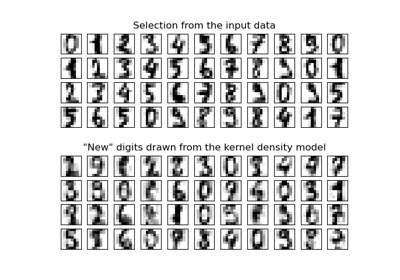

In [3]:
dataset = load_digits()
x = dataset.data
y = dataset.target

print(y)
y_cat=to_categorical(y,num_classes=10)
print(y)

x_train, x_test, y_train, y_test = train_test_split(x, y_cat, test_size=0.30)

[0 1 2 ... 8 9 8]
[0 1 2 ... 8 9 8]


In [4]:
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")

x_train shape: (1257, 64)
y_train shape: (1257, 10)


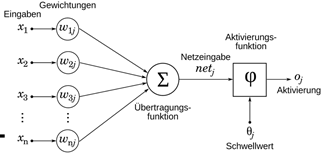

Es wird nun das Neuronale Netz aufgebaut mit der Klasse Sequential. Neuronen werden mit der Klasse Dense hinzugefügt. Die Aktivierungsfunktion wird mit Activation angegeben.

- Dense hat die Parameter Units(Anzahl der Neuronen) und input_dim (Eingangsdimension, also Anzahl der Eingänge)
- Activation: hier kann die Aktivierungsfunktion übergeben werdenn (Relu oder softmax)



In [5]:
from keras.layers import Input
model=Sequential()

model.add(Input(shape=(x.shape[1],)))               #Eingabeschicht
model.add(Dense(units=512, name='Hidden_Layer1'))
model.add(Activation("relu", name='Aktivierungsfunktion_Hidden_Layer1'))
model.add(Dense(units=256, name='Hidden_Layer2'))
model.add(Activation("relu", name='Aktivierungsfunktion_Hidden_Layer2'))
model.add(Dense(units=128, name='Hidden_Layer3'))
model.add(Activation("relu", name='Aktivierungsfunktion_Hidden_Layer3'))
model.add(Dense(units=10))                          #Ausgabeschicht
model.add(Activation("softmax"))


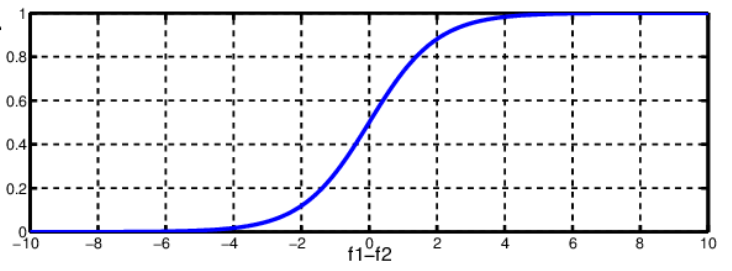

Tensorflow bietet die Möglichkeit eine Zusammenfassung des Modells sich anzeigen zu lassen

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer1 (Dense)           │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aktivierungsfunktion_Hidden_La… │ (None, 512)            │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer2 (Dense)           │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aktivierungsfunktion_Hidden_La… │ (None, 256)            │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Layer3 (Dense)           │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aktivierungsfunktion_Hidden_La… │ (None, 128)            │             0 │
│ (Activation)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,794 (776.54 KB)

 Trainable params: 198,794 (776.54 KB)

 Non-trainable params: 0 (0.00 B)

Anschließend werden die Parameter dem Neuronalen Netz übergeben
- loss: Fehlerfunktion (loss function), hier categoriacl_crossentropy (Fehlerfunktion, die bei der Klassifizierung von mehr als zwei Klassen verwendet wird.)
- optimizer: Optimierungsfunktion hier Stochastic Gradient Decent
- metrics: Ausgewählte Metrik

In [7]:
model.compile(
    loss="categorical_crossentropy", optimizer=SGD(), metrics=["accuracy"]
)

Das Model benötigt wie bei Regression und Klassifikation Trainings- und Testdaten. Die Epochenzahl wird hier auf 30 festgesetzt.

In [8]:
model.fit(x=x_train, y=y_train, epochs=30, validation_data=(x_test,y_test))

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7383 - loss: 0.9334 - val_accuracy: 0.9111 - val_loss: 0.3011
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9403 - loss: 0.2216 - val_accuracy: 0.9500 - val_loss: 0.1682
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9674 - loss: 0.1317 - val_accuracy: 0.9630 - val_loss: 0.1342
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9817 - loss: 0.0904 - val_accuracy: 0.9685 - val_loss: 0.1167
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9920 - loss: 0.0683 - val_accuracy: 0.9722 - val_loss: 0.1062
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9944 - loss: 0.0538 - val_accuracy: 0.9704 - val_loss: 0.0994
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9952 - loss: 0.0438 - val_accuracy: 0.9722 - val_loss: 0.0932
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9952 - loss: 0.0365 - val_accuracy: 0.9704 - val_loss